## Test

In [3]:
import numpy as np
import pandas as pd

# 加载 .npz 文件
data = np.load('../singleset/Holstein75_64bd_subspace.npz',allow_pickle=True)

# 'mol list', 'tempearture', 'total time', 'other info', 'r square array', 
# 'electron occupations array', 'phonon occupations array', 'k occupations array', 
# 'eph entropy', 'bond entropy', 'coherent length array', 'time series'
df = data['electron occupations array']

df = pd.DataFrame(df)

df.to_excel('Holstein75_64bd_singleset_substep.xlsx', index=False)

## Plot RMSD



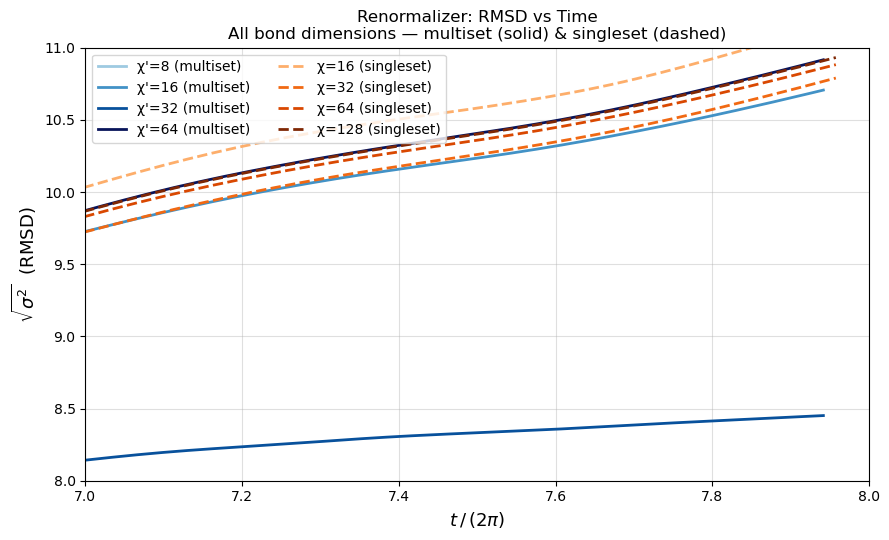

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本参数
# =========================
dt = 0.1  # a.u.

# =========================
# 计算 RMSD 的函数
# =========================
def compute_rmsd(file_path):
    df = pd.read_excel(file_path, header=None)
    occup = df.values  # shape: (Nt, Nsite)

    Nt, Nsite = occup.shape
    n0 = (Nsite - 1) / 2
    x = np.arange(Nsite)

    rmsd = np.zeros(Nt)
    for t in range(Nt):
        rho = occup[t]
        norm = np.sum(rho)
        if norm > 0:
            rho = rho / norm
        rmsd[t] = np.sqrt(np.sum((x - n0)**2 * rho))

    time_au = np.arange(Nt) * dt
    time_scaled = time_au / (2 * np.pi)
    return time_scaled, rmsd

# =========================
# 收集所有涉及的文件（去重），并标注来源组
# =========================

# multiset 组所有文件（按 bond dim 从小到大）
files_multiset = [
    ("χ'=8",   "Holstein75_8bd_multiset.xlsx"),
    ("χ'=16",  "Holstein75_16bd_multiset.xlsx"),
    ("χ'=32",  "Holstein75_32bd_multiset.xlsx"),
    ("χ'=64",  "Holstein75_64bd_multiset.xlsx"),   # 作为 χ'=32 的参考，也画出来
]

# singleset 组所有文件（按 bond dim 从小到大）
files_singleset = [
    ("χ=16",   "Holstein75_16bd_singleset.xlsx"),
    ("χ=32",   "Holstein75_32bd_singleset.xlsx"),
    ("χ=64",   "Holstein75_64bd_singleset.xlsx"),
    ("χ=128",  "Holstein75_128bd_singleset.xlsx"),  # 作为 χ=64 的参考，也画出来
]

# =========================
# 颜色配置
# multiset:  实线，蓝绿色系，bond dim 从小到大颜色从浅到深
# singleset: 虚线，橙红色系，bond dim 从小到大颜色从浅到深
# =========================
colors_multiset  = ["#9ecae1", "#4292c6", "#08519c", "#08145a"]  # 浅蓝→深蓝
colors_singleset = ["#fdae6b", "#f16913", "#d94801", "#7f2704"]  # 浅橙→深橙

# =========================
# 绘图：所有文件的 RMSD
# =========================
fig, ax = plt.subplots(figsize=(9, 5.5))

# --- multiset 组（实线）---
for (label, file_path), color in zip(files_multiset, colors_multiset):
    try:
        time, rmsd = compute_rmsd(file_path)
        ax.plot(time, rmsd, lw=2, ls="-", color=color, label=f"{label} (multiset)")
    except FileNotFoundError:
        print(f"[Warning] 文件未找到，已跳过：{file_path}")

# --- singleset 组（虚线）---
for (label, file_path), color in zip(files_singleset, colors_singleset):
    try:
        time, rmsd = compute_rmsd(file_path)
        ax.plot(time, rmsd, lw=2, ls="--", color=color, label=f"{label} (singleset)")
    except FileNotFoundError:
        print(f"[Warning] 文件未找到，已跳过：{file_path}")

# =========================
# 图像设置
# =========================
ax.set_xlim(left=7,right=8)
ax.set_ylim(bottom=8, top=11)
ax.set_xlabel(r"$t\,/\,(2\pi)$", fontsize=13)
ax.set_ylabel(r"$\sqrt{\sigma^2}$  (RMSD)", fontsize=13)
ax.set_title("Renormalizer: RMSD vs Time\n"
             "All bond dimensions — multiset (solid) & singleset (dashed)",
             fontsize=12)
ax.legend(fontsize=10, ncol=2, loc="upper left")
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
# plt.savefig("All_RMSD.png", dpi=150)
plt.show()

## related error


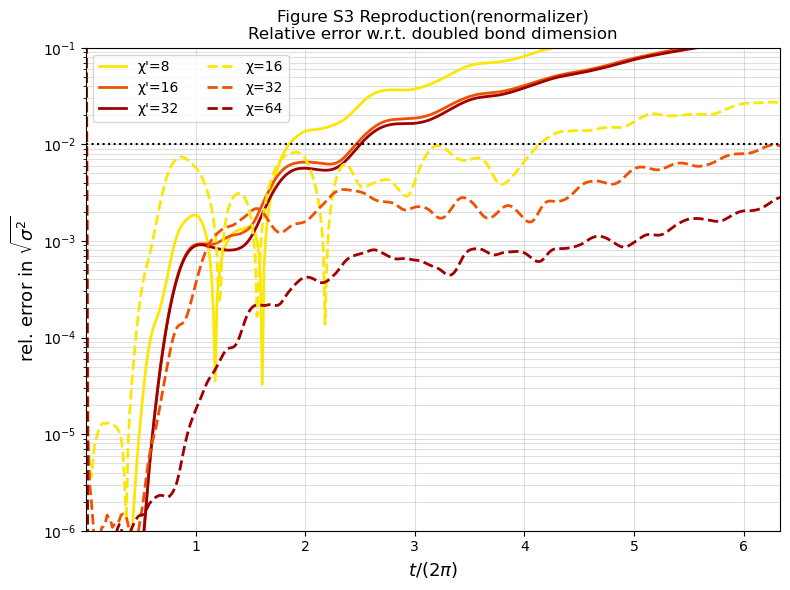

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本参数
# =========================
dt = 0.1  # a.u.

# =========================
# 计算 RMSD 的函数
# =========================
def compute_rmsd(file_path):
    df = pd.read_excel(file_path, header=None)
    occup = df.values  # shape: (Nt, Nsite)

    Nt, Nsite = occup.shape
    n0 = (Nsite - 1) / 2
    x = np.arange(Nsite)

    rmsd = np.zeros(Nt)
    for t in range(Nt):
        rho = occup[t]
        norm = np.sum(rho)
        if norm > 0:
            rho = rho / norm
        rmsd[t] = np.sqrt(np.sum((x - n0)**2 * rho))

    time_au = np.arange(Nt) * dt
    time_scaled = time_au / (2 * np.pi)
    return time_scaled, rmsd

# =========================
# 文件定义：(低bd文件, 参考=2倍bd文件)
# 严格按照文章：每条曲线的参考是其翻倍bd的计算
# =========================

# multiset 组：参考是翻倍的 multiset
pairs_multiset = [
    ("χ'=8",  "Holstein75_8bd_multiset.xlsx",   "Holstein75_16bd_multiset.xlsx"),
    ("χ'=16", "Holstein75_16bd_multiset.xlsx",  "Holstein75_32bd_multiset.xlsx"),
    ("χ'=32", "Holstein75_32bd_multiset.xlsx",  "Holstein75_64bd_multiset.xlsx"),
]

# singleset 组：参考是翻倍的 singleset
pairs_singleset = [
    ("χ=16",  "Holstein75_16bd_singleset.xlsx",  "Holstein75_32bd_singleset.xlsx"),
    ("χ=32",  "Holstein75_32bd_singleset.xlsx",  "Holstein75_64bd_singleset.xlsx"),
    ("χ=64",  "Holstein75_64bd_singleset.xlsx",  "Holstein75_128bd_singleset.xlsx"),
]

# =========================
# 颜色与线型（对照文章 S3 图）
# multiset: 实线，冷色系（文章中 multiset 是 solid）
# singleset: 虚线，暖色系（文章中 singleset 是 dashed）
# =========================
colors_multiset  = ["#fbe707", "#ef5102", "#A10000"]   # 
colors_singleset = ["#fbe707", "#ef5102", "#A10000"]   # 

# =========================
# 绘图
# =========================
fig, ax = plt.subplots(figsize=(8, 6))

# --- multiset 组（实线）---
for (label, file_low, file_ref), color in zip(pairs_multiset, colors_multiset):
    time, rmsd_low = compute_rmsd(file_low)
    _,    rmsd_ref = compute_rmsd(file_ref)

    n = min(len(rmsd_low), len(rmsd_ref))

    # 关键修正：避免 t=0 除零；从 t=1 步开始（跳过 t=0）
    # 或者使用 np.where 处理
    denom = np.abs(rmsd_ref[:n])
    numer = np.abs(rmsd_low[:n] - rmsd_ref[:n])

    # 避免除零：分母为0的地方设为nan
    with np.errstate(invalid='ignore', divide='ignore'):
        rel_err = np.where(denom > 1e-10, numer / denom, np.nan)

    ax.plot(time[:n], rel_err, lw=2, ls="-", color=color, label=label)

# --- singleset 组（虚线）---
for (label, file_low, file_ref), color in zip(pairs_singleset, colors_singleset):
    time, rmsd_low = compute_rmsd(file_low)
    _,    rmsd_ref = compute_rmsd(file_ref)

    n = min(len(rmsd_low), len(rmsd_ref))

    denom = np.abs(rmsd_ref[:n])
    numer = np.abs(rmsd_low[:n] - rmsd_ref[:n])

    with np.errstate(invalid='ignore', divide='ignore'):
        rel_err = np.where(denom > 1e-10, numer / denom, np.nan)

    ax.plot(time[:n], rel_err, lw=2, ls="--", color=color, label=label)

# =========================
# 1% 收敛阈值线（文章中的黑色虚线）
# =========================
ax.axhline(0.01, color="k", ls=":", lw=1.5)

# =========================
# 图像设置
# =========================
ax.set_yscale("log")   # 文章 S3 纵轴是对数坐标！
ax.set_xlim(1e-5, 6.333)
ax.set_ylim(1e-6, 1e-1)
ax.set_xlabel(r"$t / (2\pi)$", fontsize=13)
ax.set_ylabel(r"rel. error in $\sqrt{\sigma^2}$", fontsize=13)
ax.set_title("Figure S3 Reproduction(renormalizer)\n"
             r"Relative error w.r.t. doubled bond dimension")
ax.legend(fontsize=10, ncol=2)
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
# plt.savefig("FigS3_reproduced.png", dpi=150)
plt.show()

## MAE


,library,ansatz,chi,file,n_points
0,pyttn,multiset,8,holstein75_multiset_chi8.xlsx,501
1,renormalizer,multiset,8,Holstein75_8bd_multiset.xlsx,500
2,pyttn,multiset,16,holstein75_multiset_chi16.xlsx,501
3,pyttn,singleset,16,holstein75_singleset_chi16.xlsx,501
4,renormalizer,multiset,16,Holstein75_16bd_multiset.xlsx,500
5,renormalizer,singleset,16,Holstein75_16bd_singleset.xlsx,501
6,pyttn,multiset,32,holstein75_multiset_chi32.xlsx,501
7,pyttn,singleset,32,holstein75_singleset_chi32.xlsx,501
8,renormalizer,multiset,32,Holstein75_32bd_multiset.xlsx,500
9,renormalizer,singleset,32,Holstein75_32bd_singleset.xlsx,501


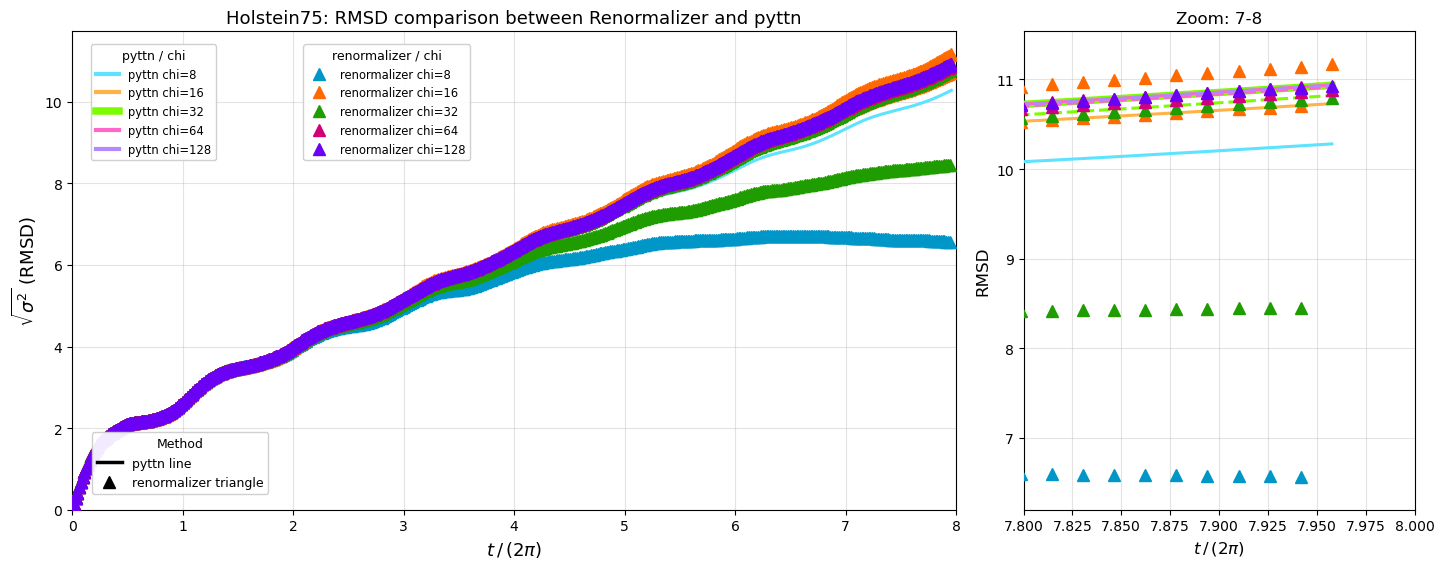

In [7]:
# =========================
# Compare Holstein75 RMSD from Renormalizer and pyttn
# =========================
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

dt = 0.1  # a.u.
zoom_window = (7.8, 8.0)
renorm_plot_dir = Path('.')
pyttn_plot_dir = Path('../../../../pyttn/test_multiset/Holstein75/plot')

chi_colors = {
    8:   {'pyttn': "#5DE2FF", 'renormalizer': "#0096C7"},
    16:  {'pyttn': "#FFB347", 'renormalizer': "#FF6A00"},
    32:  {'pyttn': "#7CFC00", 'renormalizer': "#1F9D00"},
    64:  {'pyttn': "#FF66CC", 'renormalizer': "#D1007A"},
    128: {'pyttn': "#B388FF", 'renormalizer': "#6A00F4"},
    256: {'pyttn': '#D9D9D9', 'renormalizer': "#4D4D4D"},
}
line_styles = {'multiset': '-', 'singleset': '--'}
library_order = {'pyttn': 0, 'renormalizer': 1}
ansatz_order = {'multiset': 0, 'singleset': 1}

def load_occupation_table(path, dt=dt):
    try:
        df = pd.read_excel(path, sheet_name='populations')
        site_cols = [col for col in df.columns if str(col).startswith('site_')]
        if site_cols:
            if 'time' in df.columns:
                time_au = pd.to_numeric(df['time'], errors='coerce').to_numpy(dtype=float)
            else:
                time_au = np.arange(len(df), dtype=float) * dt
            occup = df[site_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)
            occup = np.nan_to_num(occup, copy=False)
            return time_au, occup
    except ValueError:
        pass

    df = pd.read_excel(path, header=None)
    if np.array_equal(df.iloc[0].to_numpy(), np.arange(df.shape[1])):
        df = df.iloc[1:].reset_index(drop=True)
    occup = df.to_numpy(dtype=float)
    time_au = np.arange(occup.shape[0], dtype=float) * dt
    return time_au, occup

def compute_rmsd_from_occupations(time_au, occup):
    nt, nsite = occup.shape
    n0 = (nsite - 1) / 2
    x = np.arange(nsite, dtype=float)

    norm = occup.sum(axis=1, keepdims=True)
    rho = np.divide(occup, norm, out=np.zeros_like(occup), where=norm > 0)
    rmsd = np.sqrt(((x - n0) ** 2 * rho).sum(axis=1))
    return time_au / (2 * np.pi), rmsd

series = []

for path in sorted(renorm_plot_dir.glob('Holstein75_*bd_*.xlsx')):
    match = re.match(r'Holstein75_(\d+)bd_(multiset|singleset)\.xlsx$', path.name)
    if match is None:
        continue
    chi = int(match.group(1))
    ansatz = match.group(2)
    time_au, occup = load_occupation_table(path)
    time, rmsd = compute_rmsd_from_occupations(time_au, occup)
    series.append({
        'library': 'renormalizer',
        'ansatz': ansatz,
        'chi': chi,
        'file': path.name,
        'time': time,
        'rmsd': rmsd,
    })

for path in sorted(pyttn_plot_dir.glob('holstein75_*_chi*.xlsx')):
    match = re.match(r'holstein75_(multiset|singleset)_chi(\d+)\.xlsx$', path.name)
    if match is None:
        continue
    ansatz = match.group(1)
    chi = int(match.group(2))
    time_au, occup = load_occupation_table(path)
    time, rmsd = compute_rmsd_from_occupations(time_au, occup)
    series.append({
        'library': 'pyttn',
        'ansatz': ansatz,
        'chi': chi,
        'file': path.name,
        'time': time,
        'rmsd': rmsd,
    })

series = sorted(series, key=lambda x: (x['chi'], library_order[x['library']], ansatz_order[x['ansatz']]))

summary = pd.DataFrame([
    {
        'library': item['library'],
        'ansatz': item['ansatz'],
        'chi': item['chi'],
        'file': item['file'],
        'n_points': len(item['time']),
    }
    for item in series
]).sort_values(['chi', 'library', 'ansatz']).reset_index(drop=True)
display(summary)

fig, (ax, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(14.5, 5.8),
    gridspec_kw={'width_ratios': [2.6, 1.15]},
)

zoom_values = []
for item in series:
    color = chi_colors.get(item['chi'], {}).get(item['library'], None)
    linestyle = line_styles[item['ansatz']]
    label = f"{item['library']} {item['ansatz']} chi={item['chi']}"
    if item['library'] == 'renormalizer':
        ax.plot(item['time'], item['rmsd'], linestyle='None', marker='^', color=color, markersize=8.5, label=label, zorder=4)
        ax_zoom.plot(item['time'], item['rmsd'], linestyle='None', marker='^', color=color, markersize=8.5, zorder=4)
    else:
        linewidth = 5.4 if item['ansatz'] == 'multiset' and item['chi'] == 32 else 2.2
        ax.plot(item['time'], item['rmsd'], linestyle=linestyle, color=color, linewidth=linewidth, label=label, zorder=3)
        ax_zoom.plot(item['time'], item['rmsd'], linestyle=linestyle, color=color, linewidth=linewidth, zorder=3)
    mask = (item['time'] >= zoom_window[0]) & (item['time'] <= zoom_window[1])
    if np.any(mask):
        zoom_values.append(item['rmsd'][mask])

x_max = max(float(item['time'].max()) for item in series) if series else zoom_window[1]
ax.set_xlim(0, max(x_max, zoom_window[1]))
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=13)
ax.set_ylabel(r'$\sqrt{\sigma^2}$ (RMSD)', fontsize=13)
ax.set_title('Holstein75: RMSD comparison between Renormalizer and pyttn', fontsize=13)
ax.grid(True, which='both', alpha=0.35)

ax_zoom.set_xlim(*zoom_window)
if zoom_values:
    zoom_concat = np.concatenate(zoom_values)
    y_min = float(zoom_concat.min())
    y_max = float(zoom_concat.max())
    pad = max(0.01, 0.08 * (y_max - y_min))
    ax_zoom.set_ylim(max(0, y_min - pad), y_max + pad)
ax_zoom.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=12)
ax_zoom.set_ylabel('RMSD', fontsize=12)
ax_zoom.set_title('Zoom: 7-8', fontsize=12)
ax_zoom.grid(True, which='both', alpha=0.35)

pyttn_handles = [
    Line2D([0], [0], color=chi_colors[chi]['pyttn'], lw=5.4 if chi == 32 else 3, label=f'pyttn chi={chi}')
    for chi in sorted({item['chi'] for item in series if item['library'] == 'pyttn'})
]
renorm_handles = [
    Line2D([0], [0], color=chi_colors[chi]['renormalizer'], marker='^', linestyle='None', markersize=9, label=f'renormalizer chi={chi}')
    for chi in sorted({item['chi'] for item in series if item['library'] == 'renormalizer'})
]
style_handles = [
    Line2D([0], [0], color='black', lw=2.5, linestyle='-', label='pyttn line'),
    Line2D([0], [0], color='black', marker='^', linestyle='None', markersize=9, label='renormalizer triangle'),
]

legend_pyttn = ax.legend(
    handles=pyttn_handles,
    fontsize=8.3,
    title='pyttn / chi',
    title_fontsize=9,
    loc='upper left',
    bbox_to_anchor=(0.015, 0.985),
    frameon=True,
    framealpha=0.92,
)
ax.add_artist(legend_pyttn)

legend_renorm = ax.legend(
    handles=renorm_handles,
    fontsize=8.3,
    title='renormalizer / chi',
    title_fontsize=9,
    loc='upper left',
    bbox_to_anchor=(0.255, 0.985),
    frameon=True,
    framealpha=0.92,
)
ax.add_artist(legend_renorm)

ax.legend(
    handles=style_handles,
    fontsize=9,
    title='Method',
    title_fontsize=9,
    loc='lower left',
    bbox_to_anchor=(0.015, 0.02),
    frameon=True,
    framealpha=0.92,
)

fig.tight_layout()
plt.show()


### singleset Renormalizer vs Pyttn

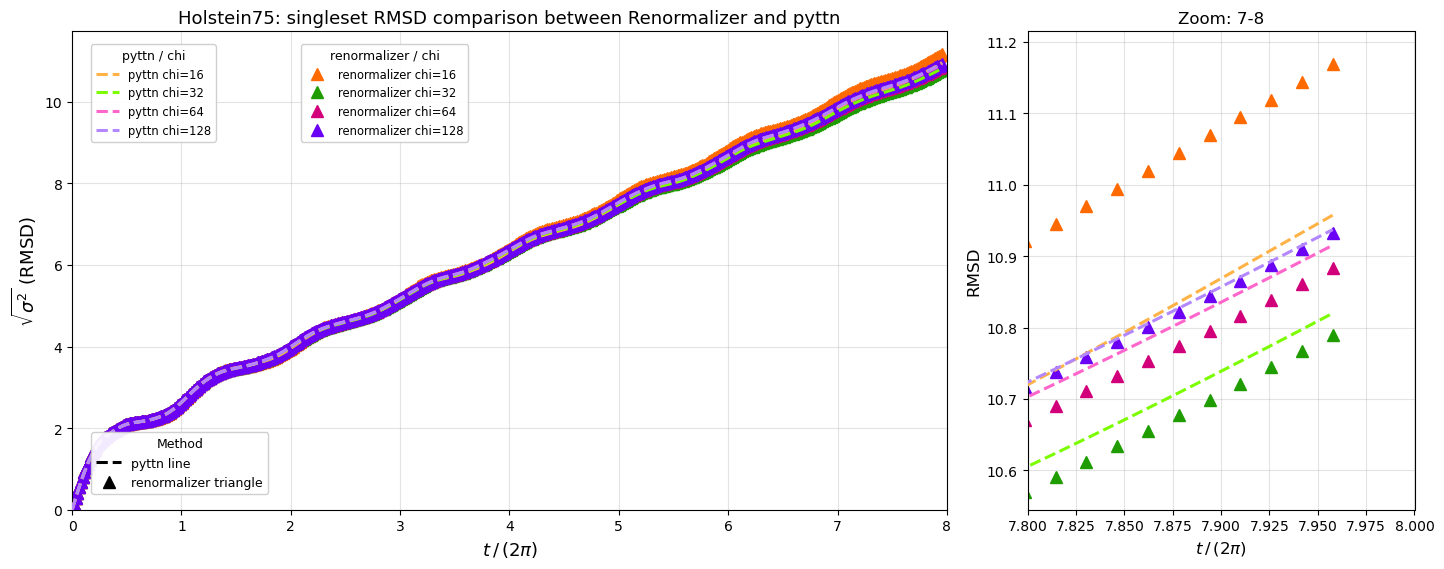

In [39]:
from matplotlib.lines import Line2D

draw_order = {'renormalizer': 0, 'pyttn': 1}
line_widths = {'pyttn': 2.2}
marker_sizes = {'renormalizer': 8.5}

def plot_ansatz_comparison(ansatz):
    subset = sorted(
        [item for item in series if item['ansatz'] == ansatz],
        key=lambda x: (x['chi'], draw_order[x['library']]),
    )
    fig, (ax, ax_zoom) = plt.subplots(
        1,
        2,
        figsize=(14.5, 5.8),
        gridspec_kw={'width_ratios': [2.6, 1.15]},
    )
    zoom_values = []
    linestyle = line_styles[ansatz]
    for item in subset:
        color = chi_colors[item['chi']][item['library']]
        zorder = 2 if item['library'] == 'renormalizer' else 3
        label = f"{item['library']} chi={item['chi']}"
        if item['library'] == 'renormalizer':
            ms = marker_sizes['renormalizer']
            ax.plot(item['time'], item['rmsd'], linestyle='None', marker='^', color=color, markersize=ms, zorder=zorder, label=label)
            ax_zoom.plot(item['time'], item['rmsd'], linestyle='None', marker='^', color=color, markersize=ms, zorder=zorder)
        else:
            lw = 5.4 if ansatz == 'multiset' and item['chi'] == 32 else line_widths['pyttn']
            ax.plot(item['time'], item['rmsd'], linestyle=linestyle, color=color, linewidth=lw, zorder=zorder, label=label)
            ax_zoom.plot(item['time'], item['rmsd'], linestyle=linestyle, color=color, linewidth=lw, zorder=zorder)
        mask = (item['time'] >= zoom_window[0]) & (item['time'] <= zoom_window[1])
        if np.any(mask):
            zoom_values.append(item['rmsd'][mask])
    x_max = max(float(item['time'].max()) for item in subset) if subset else zoom_window[1]
    ax.set_xlim(0, max(x_max, zoom_window[1]))
    ax.set_ylim(bottom=0)
    ax.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=13)
    ax.set_ylabel(r'$\sqrt{\sigma^2}$ (RMSD)', fontsize=13)
    ax.set_title(f'Holstein75: {ansatz} RMSD comparison between Renormalizer and pyttn', fontsize=13)
    ax.grid(True, which='both', alpha=0.35)
    ax_zoom.set_xlim(*zoom_window)
    if zoom_values:
        zoom_concat = np.concatenate(zoom_values)
        y_min = float(zoom_concat.min())
        y_max = float(zoom_concat.max())
        pad = max(0.01, 0.08 * (y_max - y_min))
        ax_zoom.set_ylim(max(0, y_min - pad), y_max + pad)
    ax_zoom.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=12)
    ax_zoom.set_ylabel('RMSD', fontsize=12)
    ax_zoom.set_title('Zoom: 7-8', fontsize=12)
    ax_zoom.grid(True, which='both', alpha=0.35)
    pyttn_handles = [
        Line2D([0], [0], color=chi_colors[chi]['pyttn'], lw=5.4 if ansatz == 'multiset' and chi == 32 else line_widths['pyttn'], linestyle=linestyle, label=f'pyttn chi={chi}')
        for chi in sorted({item['chi'] for item in subset if item['library'] == 'pyttn'})
    ]
    renorm_handles = [
        Line2D([0], [0], color=chi_colors[chi]['renormalizer'], marker='^', linestyle='None', markersize=9, label=f'renormalizer chi={chi}')
        for chi in sorted({item['chi'] for item in subset if item['library'] == 'renormalizer'})
    ]
    method_handles = [
        Line2D([0], [0], color='black', lw=line_widths['pyttn'], linestyle=linestyle, label='pyttn line'),
        Line2D([0], [0], color='black', marker='^', linestyle='None', markersize=9, label='renormalizer triangle'),
    ]
    legend_pyttn = ax.legend(handles=pyttn_handles, fontsize=8.3, title='pyttn / chi', title_fontsize=9, loc='upper left', bbox_to_anchor=(0.015, 0.985), frameon=True, framealpha=0.92)
    ax.add_artist(legend_pyttn)
    legend_renorm = ax.legend(handles=renorm_handles, fontsize=8.3, title='renormalizer / chi', title_fontsize=9, loc='upper left', bbox_to_anchor=(0.255, 0.985), frameon=True, framealpha=0.92)
    ax.add_artist(legend_renorm)
    ax.legend(handles=method_handles, fontsize=9, title='Method', title_fontsize=9, loc='lower left', bbox_to_anchor=(0.015, 0.02), frameon=True, framealpha=0.92)
    fig.tight_layout()
    plt.show()

plot_ansatz_comparison('singleset')


### multiset Renormalizer vs Pyttn

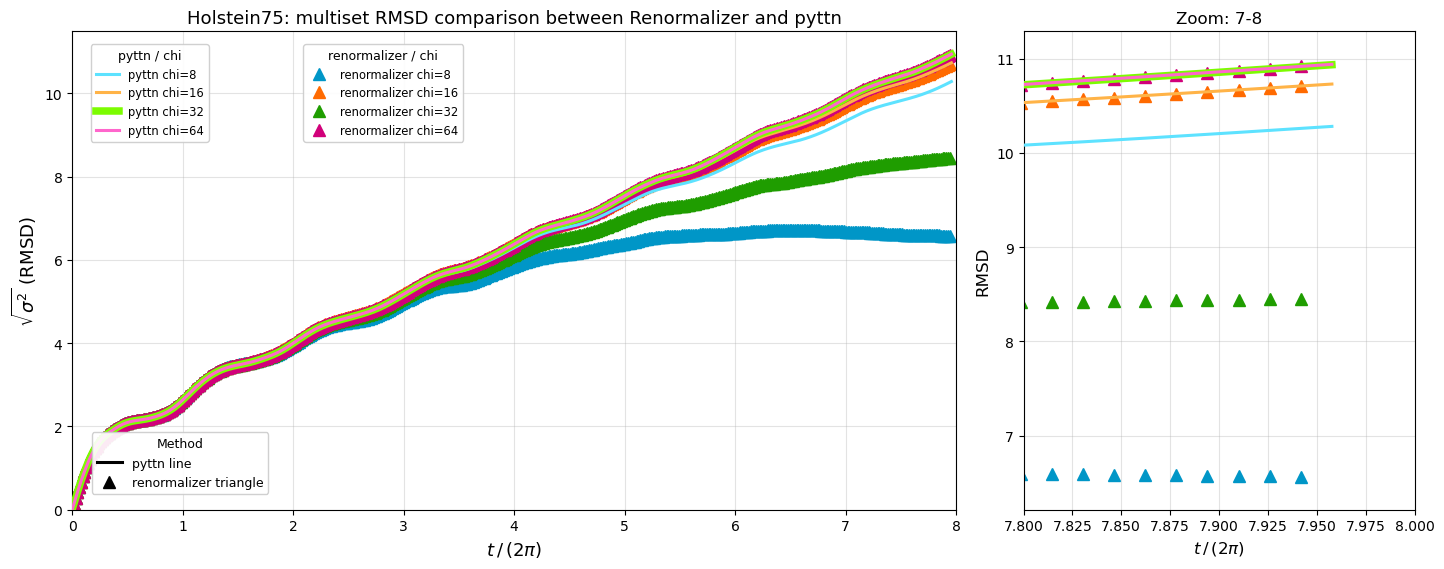

In [41]:
plot_ansatz_comparison('multiset')


### Renormalizer multiset substep RMSD

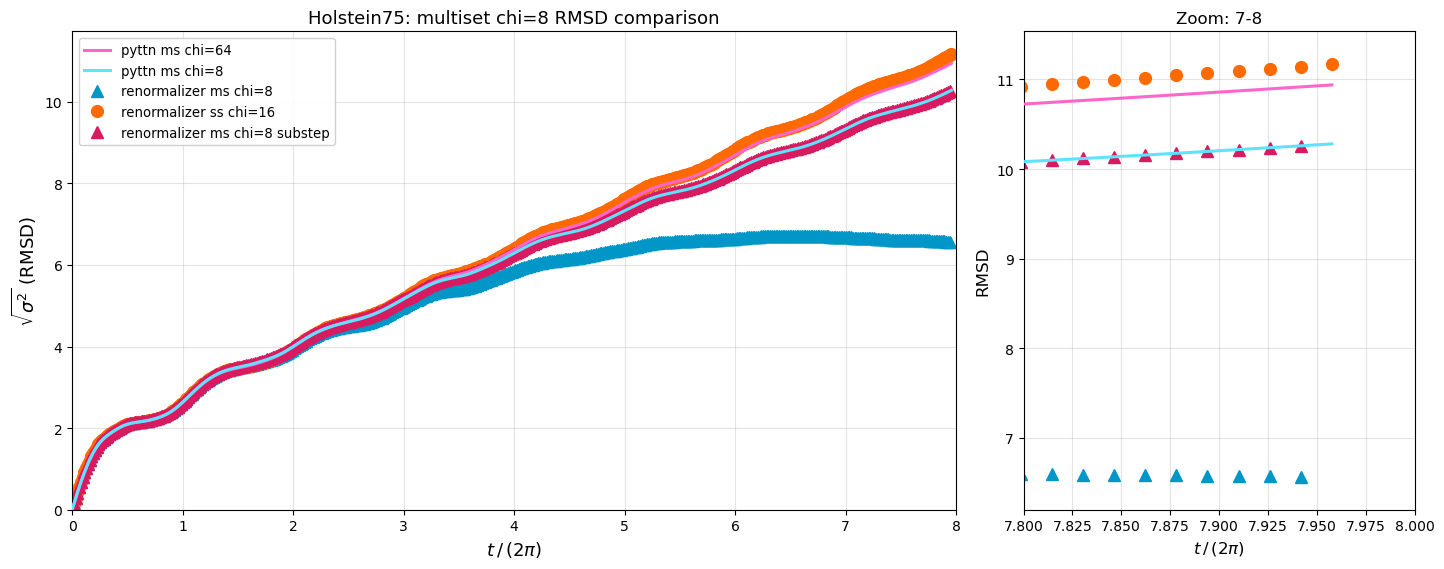

In [17]:
comparison_files = [
    {
        'label': 'pyttn ms chi=64',
        'path': pyttn_plot_dir / 'holstein75_multiset_chi64.xlsx',
        'library': 'pyttn',
        'color': chi_colors[64]['pyttn'],
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    {
        'label': 'pyttn ms chi=8',
        'path': pyttn_plot_dir / 'holstein75_multiset_chi8.xlsx',
        'library': 'pyttn',
        'color': chi_colors[8]['pyttn'],
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    {
        'label': 'renormalizer ms chi=8',
        'path': renorm_plot_dir / 'Holstein75_8bd_multiset.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[8]['renormalizer'],
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ss chi=16',
        'path': renorm_plot_dir / 'Holstein75_16bd_singleset.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[16]['renormalizer'],
        'marker': 'o',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ms chi=8 substep',
        'path': renorm_plot_dir / 'Holstein75_8bd_multiset_substep.xlsx',
        'library': 'renormalizer_substep',
        'color': '#d81b60',
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
]

fig, (ax, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(14.5, 5.8),
    gridspec_kw={'width_ratios': [2.6, 1.15]},
)

x_max = 0.0
zoom_values = []

for item in comparison_files:
    time_au, occup = load_occupation_table(item['path'])
    time, rmsd = compute_rmsd_from_occupations(time_au, occup)
    x_max = max(x_max, float(time.max()))
    if item['library'] == 'pyttn':
        ax.plot(time, rmsd, color=item['color'], linestyle=item['linestyle'], linewidth=item['linewidth'], zorder=item['zorder'], label=item['label'])
        ax_zoom.plot(time, rmsd, color=item['color'], linestyle=item['linestyle'], linewidth=item['linewidth'], zorder=item['zorder'])
    else:
        ax.plot(time, rmsd, color=item['color'], linestyle='None', marker=item['marker'], markersize=item['markersize'], zorder=item['zorder'], label=item['label'])
        ax_zoom.plot(time, rmsd, color=item['color'], linestyle='None', marker=item['marker'], markersize=item['markersize'], zorder=item['zorder'])
    mask = (time >= zoom_window[0]) & (time <= zoom_window[1])
    if np.any(mask):
        zoom_values.append(rmsd[mask])

ax.set_xlim(0, max(x_max, zoom_window[1]))
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=13)
ax.set_ylabel(r'$\sqrt{\sigma^2}$ (RMSD)', fontsize=13)
ax.set_title('Holstein75: multiset chi=8 RMSD comparison', fontsize=13)
ax.grid(True, which='both', alpha=0.35)

ax_zoom.set_xlim(*zoom_window)
if zoom_values:
    zoom_concat = np.concatenate(zoom_values)
    y_min = float(zoom_concat.min())
    y_max = float(zoom_concat.max())
    pad = max(0.01, 0.08 * (y_max - y_min))
    ax_zoom.set_ylim(max(0, y_min - pad), y_max + pad)
ax_zoom.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=12)
ax_zoom.set_ylabel('RMSD', fontsize=12)
ax_zoom.set_title('Zoom: 7-8', fontsize=12)
ax_zoom.grid(True, which='both', alpha=0.35)

ax.legend(fontsize=9.5, loc='upper left', frameon=True, framealpha=0.92)
fig.tight_layout()
plt.show()


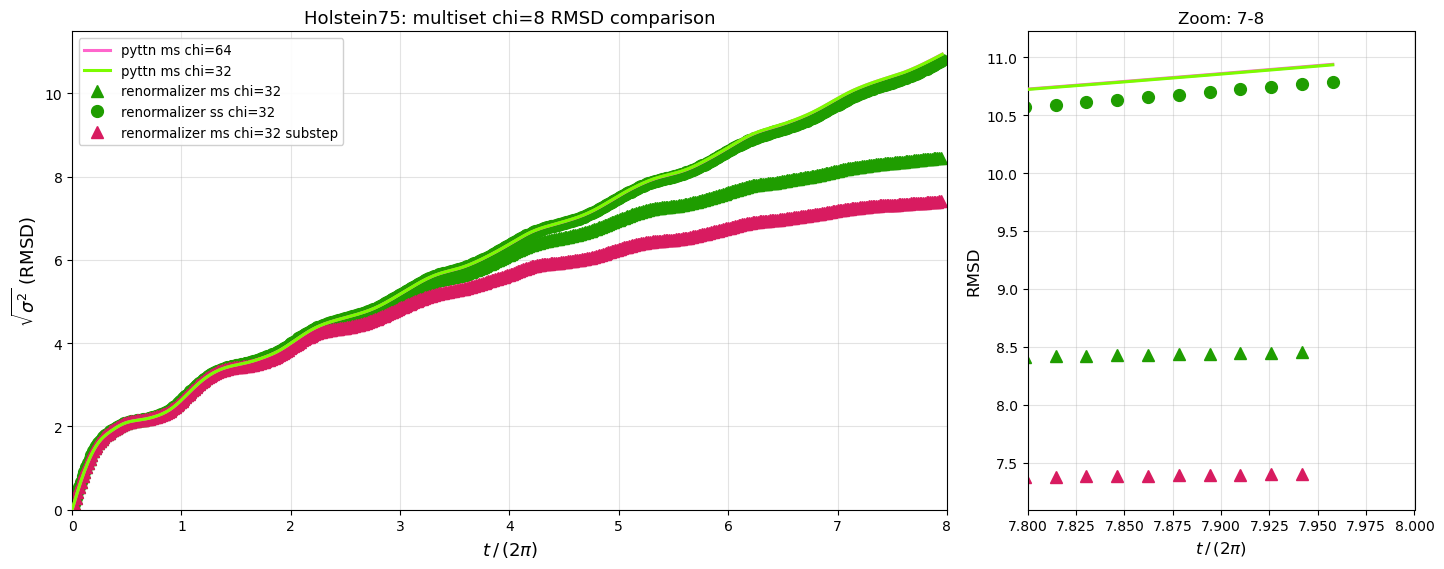

In [18]:
comparison_files = [
    {
        'label': 'pyttn ms chi=64',
        'path': pyttn_plot_dir / 'holstein75_multiset_chi64.xlsx',
        'library': 'pyttn',
        'color': chi_colors[64]['pyttn'],
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    {
        'label': 'pyttn ms chi=32',
        'path': pyttn_plot_dir / 'holstein75_multiset_chi32.xlsx',
        'library': 'pyttn',
        'color': chi_colors[32]['pyttn'],
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    {
        'label': 'renormalizer ms chi=32',
        'path': renorm_plot_dir / 'Holstein75_32bd_multiset.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[32]['renormalizer'],
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ss chi=32',
        'path': renorm_plot_dir / 'Holstein75_32bd_singleset.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[32]['renormalizer'],
        'marker': 'o',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ms chi=32 substep',
        'path': renorm_plot_dir / 'Holstein75_32bd_multiset_substep.xlsx',
        'library': 'renormalizer_substep',
        'color': '#d81b60',
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
]

fig, (ax, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(14.5, 5.8),
    gridspec_kw={'width_ratios': [2.6, 1.15]},
)

x_max = 0.0
zoom_values = []

for item in comparison_files:
    time_au, occup = load_occupation_table(item['path'])
    time, rmsd = compute_rmsd_from_occupations(time_au, occup)
    x_max = max(x_max, float(time.max()))
    if item['library'] == 'pyttn':
        ax.plot(time, rmsd, color=item['color'], linestyle=item['linestyle'], linewidth=item['linewidth'], zorder=item['zorder'], label=item['label'])
        ax_zoom.plot(time, rmsd, color=item['color'], linestyle=item['linestyle'], linewidth=item['linewidth'], zorder=item['zorder'])
    else:
        ax.plot(time, rmsd, color=item['color'], linestyle='None', marker=item['marker'], markersize=item['markersize'], zorder=item['zorder'], label=item['label'])
        ax_zoom.plot(time, rmsd, color=item['color'], linestyle='None', marker=item['marker'], markersize=item['markersize'], zorder=item['zorder'])
    mask = (time >= zoom_window[0]) & (time <= zoom_window[1])
    if np.any(mask):
        zoom_values.append(rmsd[mask])

ax.set_xlim(0, max(x_max, zoom_window[1]))
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=13)
ax.set_ylabel(r'$\sqrt{\sigma^2}$ (RMSD)', fontsize=13)
ax.set_title('Holstein75: multiset chi=8 RMSD comparison', fontsize=13)
ax.grid(True, which='both', alpha=0.35)

ax_zoom.set_xlim(*zoom_window)
if zoom_values:
    zoom_concat = np.concatenate(zoom_values)
    y_min = float(zoom_concat.min())
    y_max = float(zoom_concat.max())
    pad = max(0.01, 0.08 * (y_max - y_min))
    ax_zoom.set_ylim(max(0, y_min - pad), y_max + pad)
ax_zoom.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=12)
ax_zoom.set_ylabel('RMSD', fontsize=12)
ax_zoom.set_title('Zoom: 7-8', fontsize=12)
ax_zoom.grid(True, which='both', alpha=0.35)

ax.legend(fontsize=9.5, loc='upper left', frameon=True, framealpha=0.92)
fig.tight_layout()
plt.show()


### Renormalizer singleset substep RMSD

/tmp/ipykernel_1416920/1016485911.py:58: RuntimeWarning: invalid value encountered in sqrt
  rmsd = np.sqrt(((x - n0) ** 2 * rho).sum(axis=1))


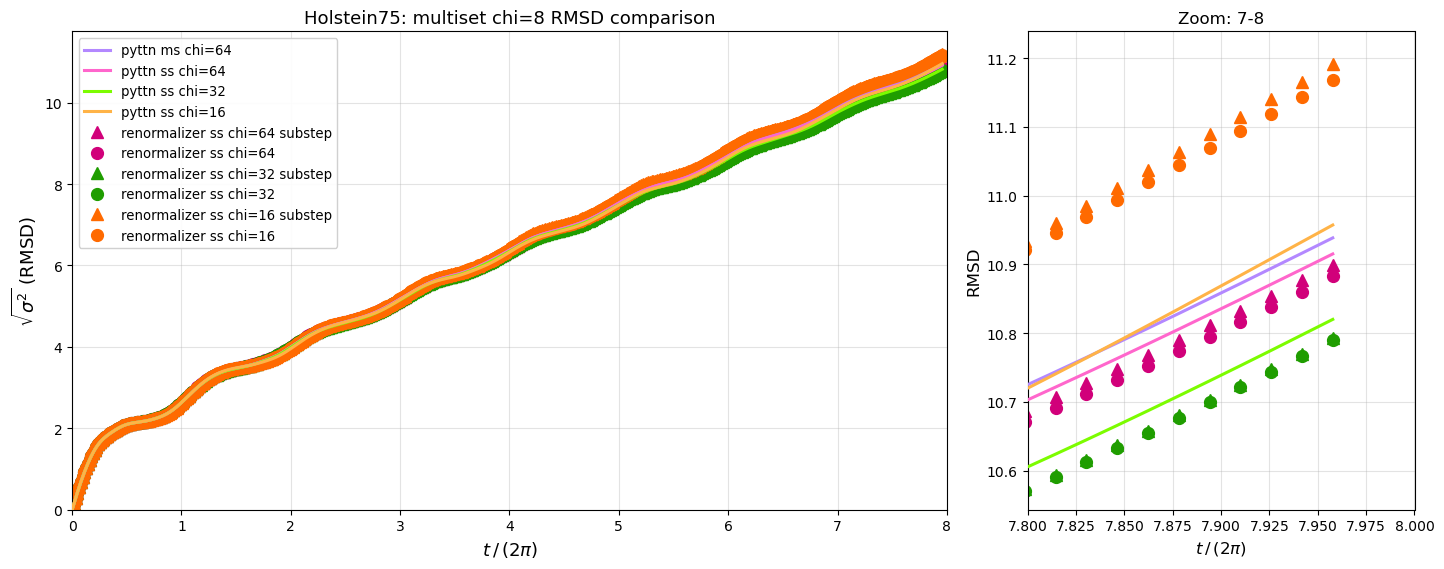

In [14]:
from pathlib import Path
pyttn_plot_dir = Path('../../../../pyttn/test_multiset/Holstein75/plot')
comparison_files = [
    {
        'label': 'pyttn ms chi=64',
        'path': pyttn_plot_dir / 'holstein75_multiset_chi64.xlsx',
        'library': 'pyttn',
        'color': chi_colors[128]['pyttn'],
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    {
        'label': 'pyttn ss chi=64',
        'path': pyttn_plot_dir / 'holstein75_singleset_chi64.xlsx',
        'library': 'pyttn',
        'color': chi_colors[64]['pyttn'],
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    {
        'label': 'pyttn ss chi=32',
        'path': pyttn_plot_dir / 'holstein75_singleset_chi32.xlsx',
        'library': 'pyttn',
        'color': chi_colors[32]['pyttn'],
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    {
        'label': 'pyttn ss chi=16',
        'path': pyttn_plot_dir / 'holstein75_singleset_chi16.xlsx',
        'library': 'pyttn',
        'color': chi_colors[16]['pyttn'],
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    {
        'label': 'renormalizer ss chi=64 substep',
        'path': renorm_plot_dir / 'Holstein75_64bd_singleset_substep.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[64]['renormalizer'],
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ss chi=64',
        'path': renorm_plot_dir / 'Holstein75_64bd_singleset.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[64]['renormalizer'],
        'marker': 'o',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ss chi=32 substep',
        'path': renorm_plot_dir / 'Holstein75_32bd_singleset_substep.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[32]['renormalizer'],
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ss chi=32',
        'path': renorm_plot_dir / 'Holstein75_32bd_singleset.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[32]['renormalizer'],
        'marker': 'o',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ss chi=16 substep',
        'path': renorm_plot_dir / 'Holstein75_16bd_singleset_substep.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[16]['renormalizer'],
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ss chi=16',
        'path': renorm_plot_dir / 'Holstein75_16bd_singleset.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[16]['renormalizer'],
        'marker': 'o',
        'markersize': 8.5,
        'zorder': 2,
    },
]

fig, (ax, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(14.5, 5.8),
    gridspec_kw={'width_ratios': [2.6, 1.15]},
)

x_max = 0.0
zoom_values = []

for item in comparison_files:
    time_au, occup = load_occupation_table(item['path'])
    time, rmsd = compute_rmsd_from_occupations(time_au, occup)
    x_max = max(x_max, float(time.max()))
    if item['library'] == 'pyttn':
        ax.plot(time, rmsd, color=item['color'], linestyle=item['linestyle'], linewidth=item['linewidth'], zorder=item['zorder'], label=item['label'])
        ax_zoom.plot(time, rmsd, color=item['color'], linestyle=item['linestyle'], linewidth=item['linewidth'], zorder=item['zorder'])
    else:
        ax.plot(time, rmsd, color=item['color'], linestyle='None', marker=item['marker'], markersize=item['markersize'], zorder=item['zorder'], label=item['label'])
        ax_zoom.plot(time, rmsd, color=item['color'], linestyle='None', marker=item['marker'], markersize=item['markersize'], zorder=item['zorder'])
    mask = (time >= zoom_window[0]) & (time <= zoom_window[1])
    if np.any(mask):
        zoom_values.append(rmsd[mask])

ax.set_xlim(0, max(x_max, zoom_window[1]))
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=13)
ax.set_ylabel(r'$\sqrt{\sigma^2}$ (RMSD)', fontsize=13)
ax.set_title('Holstein75: multiset chi=8 RMSD comparison', fontsize=13)
ax.grid(True, which='both', alpha=0.35)

ax_zoom.set_xlim(*zoom_window)
if zoom_values:
    zoom_concat = np.concatenate(zoom_values)
    y_min = float(zoom_concat.min())
    y_max = float(zoom_concat.max())
    pad = max(0.01, 0.08 * (y_max - y_min))
    ax_zoom.set_ylim(max(0, y_min - pad), y_max + pad)
ax_zoom.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=12)
ax_zoom.set_ylabel('RMSD', fontsize=12)
ax_zoom.set_title('Zoom: 7-8', fontsize=12)
ax_zoom.grid(True, which='both', alpha=0.35)

ax.legend(fontsize=9.5, loc='upper left', frameon=True, framealpha=0.92)
fig.tight_layout()
plt.show()


### multiset substep comparsion

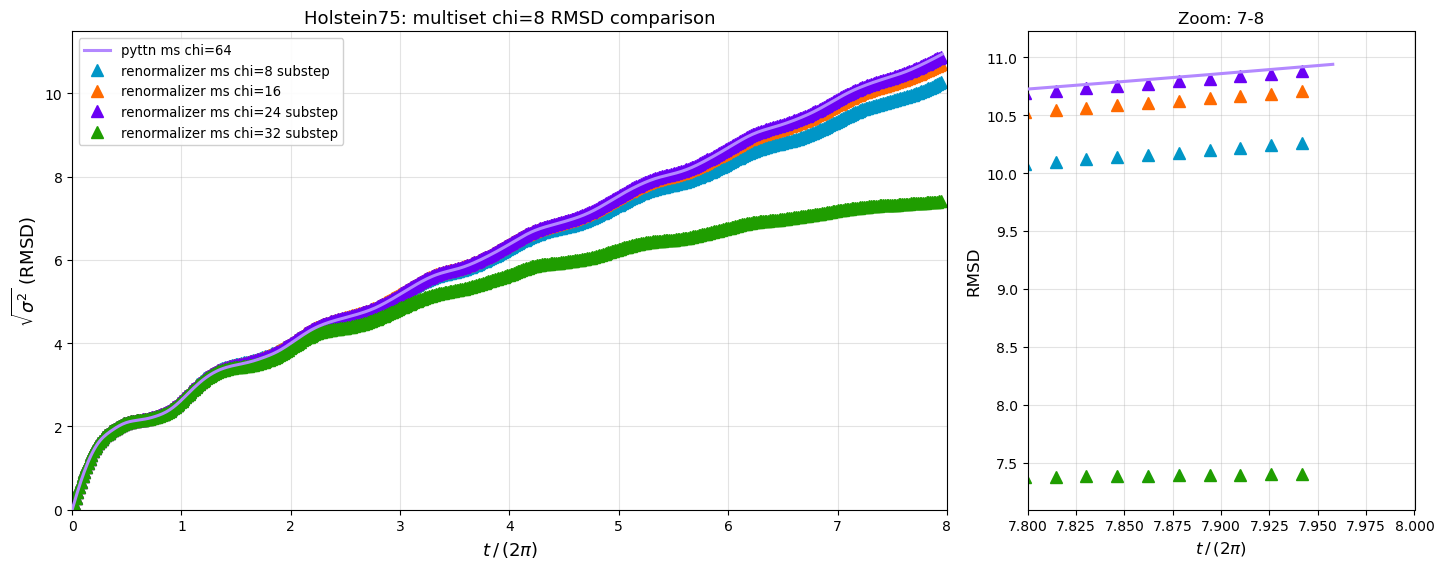

In [23]:
from pathlib import Path
pyttn_plot_dir = Path('../../../../pyttn/test_multiset/Holstein75/plot')
comparison_files = [
    {
        'label': 'pyttn ms chi=64',
        'path': pyttn_plot_dir / 'holstein75_multiset_chi64.xlsx',
        'library': 'pyttn',
        'color': chi_colors[128]['pyttn'],
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    {
        'label': 'renormalizer ms chi=8 substep',
        'path': renorm_plot_dir / 'Holstein75_8bd_multiset_substep.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[8]['renormalizer'],
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ms chi=16',
        'path': renorm_plot_dir / 'Holstein75_16bd_multiset.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[16]['renormalizer'],
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ms chi=24 substep',
        'path': renorm_plot_dir / 'Holstein75_24bd_multiset_substep.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[128]['renormalizer'],
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ms chi=32 substep',
        'path': renorm_plot_dir / 'Holstein75_32bd_multiset_substep.xlsx',
        'library': 'renormalizer',
        'color': chi_colors[32]['renormalizer'],
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
]

fig, (ax, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(14.5, 5.8),
    gridspec_kw={'width_ratios': [2.6, 1.15]},
)

x_max = 0.0
zoom_values = []

for item in comparison_files:
    time_au, occup = load_occupation_table(item['path'])
    time, rmsd = compute_rmsd_from_occupations(time_au, occup)
    x_max = max(x_max, float(time.max()))
    if item['library'] == 'pyttn':
        ax.plot(time, rmsd, color=item['color'], linestyle=item['linestyle'], linewidth=item['linewidth'], zorder=item['zorder'], label=item['label'])
        ax_zoom.plot(time, rmsd, color=item['color'], linestyle=item['linestyle'], linewidth=item['linewidth'], zorder=item['zorder'])
    else:
        ax.plot(time, rmsd, color=item['color'], linestyle='None', marker=item['marker'], markersize=item['markersize'], zorder=item['zorder'], label=item['label'])
        ax_zoom.plot(time, rmsd, color=item['color'], linestyle='None', marker=item['marker'], markersize=item['markersize'], zorder=item['zorder'])
    mask = (time >= zoom_window[0]) & (time <= zoom_window[1])
    if np.any(mask):
        zoom_values.append(rmsd[mask])

ax.set_xlim(0, max(x_max, zoom_window[1]))
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=13)
ax.set_ylabel(r'$\sqrt{\sigma^2}$ (RMSD)', fontsize=13)
ax.set_title('Holstein75: multiset chi=8 RMSD comparison', fontsize=13)
ax.grid(True, which='both', alpha=0.35)

ax_zoom.set_xlim(*zoom_window)
if zoom_values:
    zoom_concat = np.concatenate(zoom_values)
    y_min = float(zoom_concat.min())
    y_max = float(zoom_concat.max())
    pad = max(0.01, 0.08 * (y_max - y_min))
    ax_zoom.set_ylim(max(0, y_min - pad), y_max + pad)
ax_zoom.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=12)
ax_zoom.set_ylabel('RMSD', fontsize=12)
ax_zoom.set_title('Zoom: 7-8', fontsize=12)
ax_zoom.grid(True, which='both', alpha=0.35)

ax.legend(fontsize=9.5, loc='upper left', frameon=True, framealpha=0.92)
fig.tight_layout()
plt.show()
